# Processing Data Mobil Bekas (mobil123)

Notebook ini mencakup proses lengkap mulai dari pembersihan data mentah hasil scraping,
pemisahan kolom `ellipsize` menjadi `tahun`, `merk`, dan `tipe`, eksplorasi data (EDA),
sampai contoh regresi linear untuk memprediksi harga mobil bekas.

**Alur notebook:**
1. Load data mentah
2. Pembersihan & ekstraksi kolom (`tahun`, `merk`, `tipe`, `km`, `harga`, `lokasi`, `penjual`)
3. Ringkasan kualitas data (missing value, baris yang datanya tidak lengkap)
4. EDA (eksplorasi & visualisasi)
5. Regresi linear (harga sebagai target)

> **Catatan:** baris yang harganya kosong di sumber data **tetap disimpan** dengan nilai `NaN`
> (tidak di-drop maupun ditebak dari teks deskripsi), supaya bisa dianalisis/diputuskan sendiri
> lebih lanjut sebelum dipakai ke model.


## 1. Load Data

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 80)

RAW_PATH = '/mnt/user-data/uploads/mobil123_raw.csv'

df_raw = pd.read_csv(RAW_PATH)
print("Shape awal (termasuk baris kosong):", df_raw.shape)

# baris yang seluruh kolomnya kosong dibuang (artefak hasil scraping, tidak ada data sama sekali)
df = df_raw.dropna(how='all').reset_index(drop=True)
print("Shape setelah buang baris yang seluruh kolomnya kosong:", df.shape)

df.head()


Load Data Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 80)

RAW_PATH = '/content/drive/MyDrive/SEMESTER II/BDAPA/Teori/Final Project/mobil123/insyaalloh jadi/mobil123_raw.csv'

df_raw = pd.read_csv(RAW_PATH)
print("Shape awal (termasuk baris kosong):", df_raw.shape)

# baris yang seluruh kolomnya kosong dibuang (artefak hasil scraping, tidak ada data sama sekali)
df = df_raw.dropna(how='all').reset_index(drop=True)
print("Shape setelah buang baris yang seluruh kolomnya kosong:", df.shape)

df.head()

Shape awal (termasuk baris kosong): (2061, 8)
Shape setelah buang baris yang seluruh kolomnya kosong: (1975, 8)


,listing__rating-model,item,item 2,item 3,item 4,ellipsize,listing__excerpt,listing__price
0,Lexus RX 270,85000 KM,Automatic,DKI Jakarta,Dealer,2013 Lexus RX 270 2.7 SUV - RX270 Ultimate Atpm 2014 nik h...,Kondisi istimewa Fresh original seperti baru Tangan pertama dari baru Nama p...,Rp 230.000.000
1,Toyota Rush,40 - 45K KM,Automatic,Jawa Barat,Sales Agent,2019 Toyota Rush 1.5 TRD Sportivo SUV,Mobil Bekas Rasa Mobil Baru Harga SUDAH DIBAWAH PASARAN Unit Ready 2019 Toyo...,NaN
2,Suzuki XL7,55 - 60K KM,Automatic,DKI Jakarta,Dealer,2022 Suzuki XL7 1.5 Beta SUV - Matic,"Suzuki XL 7 2022 A/T Harga untuk kredit Rp.189.000.000,- .Plat B .Type Betha...",Rp 189.000.000
3,Toyota Rush,95 - 100K KM,Automatic,Jawa Barat,Dealer,"2017 Toyota Rush 1.5 TRD Sportivo SUV - UNIT ISTIMEWA, PER...","Bisa Cash/ Bisa Kredit OTR Kredit 157 JT OTR Cash 162 JT Harga, DP dan simul...",NaN
4,NaN,0 - 5K KM,Automatic,DKI Jakarta,Dealer,2025 Volvo XC60 2.0 Recharge PHEV SUV,VOLVO XC60 T8 AWD RECHARGE FACELIFT NIK 2025 FOREST LAKE GREEN ON LIGHT BEIG...,NaN


## 2. Pembersihan & Ekstraksi Kolom

### 2.1 Pisahkan `ellipsize` -> `tahun`, dan gabungkan dengan `listing__rating-model` -> `merk`, `tipe`

Kolom `ellipsize` formatnya konsisten: `"<tahun> <merk> <tipe...>"`, dan **tahun selalu 4 digit
di awal** untuk seluruh baris (sudah dicek, 0 baris yang menyimpang dari pola ini).

Untuk **merk** dan **tipe**, sumber utamanya adalah kolom `listing__rating-model` karena isinya
lebih bersih ("Merk Tipe", tanpa noise teks promo). Kolom `ellipsize` dipakai sebagai **fallback**
untuk baris yang `listing__rating-model`-nya kosong -- tapi perlu diketahui bahwa sekitar **40% dari
seluruh baris** punya `ellipsize` yang terpotong dengan `"..."` (teks aslinya di-truncate saat
scraping), sehingga tipe hasil fallback bisa saja tidak lengkap. Baris-baris ini ditandai lewat
kolom boolean `tipe_truncated` agar mudah diaudit, bukan diam-diam disimpan sebagai data lengkap.

Merk dua kata (seperti "Land Rover", "Mercedes-Benz") ditangani secara eksplisit supaya tidak
salah terpotong jadi satu kata saja.


In [4]:
MULTI_WORD_BRANDS = ['Land Rover', 'Mercedes-Benz', 'Aston Martin', 'Alfa Romeo']

# Body type yang biasa muncul di EKOR string `ellipsize` (SUV, MPV, dst). Di `ellipsize`
# formatnya konsisten '<tahun> <merk> <tipe> <cc> <BODYTYPE> - <promo text>', jadi body
# type selalu kata TERAKHIR sebelum ' - ' atau '...'. Di `tipe` (yang diambil dari
# listing__rating-model) body type ini TIDAK ADA -- makanya ekstraksi jenis mobil harus
# dilakukan dari `ellipsize`, bukan dari `tipe`.
BODY_TYPE_PREFIXES = ['SUV', 'MPV', 'Sedan', 'Hatchback', 'PHEV', 'Coupe',
                      'Convertible', 'Pickup', 'Truck', 'Van', 'Fastback', 'Wagon']


def extract_year(ellipsize_text):
    """Ambil 4 digit pertama dari ellipsize sebagai tahun."""
    m = re.match(r'^(\d{4})', str(ellipsize_text))
    return int(m.group(1)) if m else None


def split_brand_type(model_text):
    """Pisahkan 'Merk Tipe...' (dari listing__rating-model) jadi (merk, tipe)."""
    if pd.isna(model_text):
        return None, None
    for mw in MULTI_WORD_BRANDS:
        if model_text.startswith(mw):
            return mw, model_text[len(mw):].strip() or None
    parts = model_text.split(' ', 1)
    merk = parts[0]
    tipe = parts[1] if len(parts) > 1 else None
    return merk, tipe


def from_ellipsize(ellipsize_text):
    """Fallback: pisahkan merk & tipe langsung dari ellipsize (dipakai kalau
    listing__rating-model kosong). Buang dulu tahun di awal & ekor ' - ...' (promo text)."""
    text_wo_year = re.sub(r'^\d{4}\s+', '', str(ellipsize_text))
    text_wo_year = text_wo_year.split(' - ')[0]
    for mw in MULTI_WORD_BRANDS:
        if text_wo_year.startswith(mw):
            return mw, text_wo_year[len(mw):].strip() or None
    parts = text_wo_year.split(' ', 1)
    merk = parts[0]
    tipe = parts[1] if len(parts) > 1 else None
    return merk, tipe


def trim_trailing_bodytype(tipe_text):
    """Buang cc desimal (2.0, 1.5, dst) di mana saja, lalu buang body type HANYA
    kalau itu kata TERAKHIR (bukan exact-match di tengah) -- supaya 'Karimun Wagon R'
    tidak salah terpotong jadi 'Karimun R' hanya karena ada kata 'Wagon' di tengahnya."""
    if pd.isna(tipe_text):
        return tipe_text
    words = tipe_text.split()
    words = [w for w in words if not re.match(r'^\d+\.\d+$', w)]
    while words:
        last = words[-1].rstrip('.')
        is_bodytype = any(last == bt or (len(last) >= 3 and bt.startswith(last))
                           for bt in BODY_TYPE_PREFIXES)
        if is_bodytype:
            words.pop()
        else:
            break
    return ' '.join(words).strip()


def extract_body_type(ellipsize_text):
    """Ambil jenis mobil (SUV/MPV/Sedan/dst) dari kata terakhir di `ellipsize`
    (sebelum ' - ' promo text atau '...' truncation). Diambil dari `ellipsize`
    (bukan dari `tipe`/listing__rating-model) karena body type cuma muncul di
    ellipsize yang teksnya lebih lengkap. Exact match saja (tanpa startswith)
    supaya tidak salah tangkap kata lain yang kebetulan mirip prefix.
    Return None kalau ekor ellipsize bukan body type yang dikenali."""
    text = str(ellipsize_text)
    core = text.split(' - ')[0]
    core = re.sub(r'\.\.\.$', '', core).strip()
    words = core.split()
    if not words:
        return None
    last = words[-1].rstrip('.')
    for bt in BODY_TYPE_PREFIXES:
        if last == bt:
            return bt
    return None


In [5]:
# --- Tahun: selalu dari ellipsize ---
df['tahun'] = df['ellipsize'].apply(extract_year)

# --- Jenis mobil (SUV/MPV/Sedan/dst): diambil dari ellipsize SEBELUM tipe diproses,
#     karena body type hanya muncul di ellipsize, tidak ada di listing__rating-model ---
df['jenis_mobil'] = df['ellipsize'].apply(extract_body_type)

n_jenis_kosong = df['jenis_mobil'].isna().sum()
print(f"Baris tanpa jenis mobil terdeteksi: {n_jenis_kosong} dari {len(df)}")
print()
print("Distribusi jenis_mobil:")
print(df['jenis_mobil'].value_counts(dropna=False))

# --- Merk & tipe: prioritas dari listing__rating-model ---
merk_tipe = df['listing__rating-model'].apply(split_brand_type)
df['merk'] = merk_tipe.apply(lambda x: x[0])
df['tipe'] = merk_tipe.apply(lambda x: x[1])
df['tipe_truncated'] = False  # flag default: data tipe dianggap lengkap

# --- Fallback ke ellipsize untuk baris yang listing__rating-model kosong ---
mask_fallback = df['merk'].isna()
print(f"\nBaris yang fallback ke ellipsize (listing__rating-model kosong): {mask_fallback.sum()}")

for i in df[mask_fallback].index:
    merk, tipe = from_ellipsize(df.loc[i, 'ellipsize'])
    df.loc[i, 'merk'] = merk
    df.loc[i, 'tipe'] = tipe
    if str(df.loc[i, 'ellipsize']).endswith('...'):
        df.loc[i, 'tipe_truncated'] = True

# --- Bersihkan ekor tipe (cc & body type) untuk SEMUA baris ---
# (body type sudah diselamatkan ke kolom jenis_mobil di atas, jadi aman dibuang dari sini)
df['tipe'] = df['tipe'].str.split(' - ').str[0]
df['tipe'] = df['tipe'].str.replace(r'\.\.\.$', '', regex=True).str.strip()
df['tipe'] = df['tipe'].apply(trim_trailing_bodytype)

print(f"Baris dengan tipe_truncated=True (tipe kemungkinan tidak lengkap): {df['tipe_truncated'].sum()}")

# --- Kolom dummy/one-hot untuk tiap jenis mobil (is_suv, is_mpv, dst) ---
# Baris yang jenis_mobil-nya None otomatis dapat 0 di semua kolom dummy (bukan dibuang).
dummy_jenis = pd.get_dummies(df['jenis_mobil'], prefix='is').astype(int)
dummy_jenis.columns = [c.lower() for c in dummy_jenis.columns]
df = pd.concat([df, dummy_jenis], axis=1)

print("\nKolom dummy jenis mobil yang dibuat:", dummy_jenis.columns.tolist())

df[['ellipsize', 'merk', 'tipe', 'jenis_mobil'] + dummy_jenis.columns.tolist()].head(10)


Baris tanpa jenis mobil terdeteksi: 53 dari 1975

Distribusi jenis_mobil:
jenis_mobil
SUV            840
MPV            512
Sedan          241
Hatchback      215
Coupe           73
None            53
Truck            9
Convertible      8
Pickup           8
Wagon            6
Van              5
Fastback         5
Name: count, dtype: int64

Baris yang fallback ke ellipsize (listing__rating-model kosong): 490
Baris dengan tipe_truncated=True (tipe kemungkinan tidak lengkap): 212

Kolom dummy jenis mobil yang dibuat: ['is_convertible', 'is_coupe', 'is_fastback', 'is_hatchback', 'is_mpv', 'is_pickup', 'is_suv', 'is_sedan', 'is_truck', 'is_van', 'is_wagon']


,ellipsize,merk,tipe,jenis_mobil,is_convertible,is_coupe,is_fastback,is_hatchback,is_mpv,is_pickup,is_suv,is_sedan,is_truck,is_van,is_wagon
0,2013 Lexus RX 270 2.7 SUV - RX270 Ultimate Atpm 2014 nik h...,Lexus,RX 270,SUV,0,0,0,0,0,0,1,0,0,0,0
1,2019 Toyota Rush 1.5 TRD Sportivo SUV,Toyota,Rush,SUV,0,0,0,0,0,0,1,0,0,0,0
2,2022 Suzuki XL7 1.5 Beta SUV - Matic,Suzuki,XL7,SUV,0,0,0,0,0,0,1,0,0,0,0
3,"2017 Toyota Rush 1.5 TRD Sportivo SUV - UNIT ISTIMEWA, PER...",Toyota,Rush,SUV,0,0,0,0,0,0,1,0,0,0,0
4,2025 Volvo XC60 2.0 Recharge PHEV SUV,Volvo,XC60 Recharge,SUV,0,0,0,0,0,0,1,0,0,0,0
5,2024 Hyundai Santa Fe 2.5 Calligraphy SUV - Low KM,Hyundai,Santa Fe,SUV,0,0,0,0,0,0,1,0,0,0,0
6,2019 Mercedes-Benz C200 2.0 Avantgarde Line Sedan - TDP 50...,Mercedes-Benz,C200,Sedan,0,0,0,0,0,0,0,1,0,0,0
7,2022 Mazda CX-5 2.5 Kuro Edition SUV,Mazda,CX-5,SUV,0,0,0,0,0,0,1,0,0,0,0
8,2020 Suzuki Karimun Wagon R 1.0 GS Hatchback,Suzuki,Karimun Wagon R,Hatchback,0,0,0,1,0,0,0,0,0,0,0
9,2019 Chevrolet TRAX 1.4 Premier SUV,Chevrolet,TRAX,SUV,0,0,0,0,0,0,1,0,0,0,0


### 2.2 Parsing `km` (kolom `item`)

Format `km` di data ini campur antara angka pasti ("85000 KM") dan rentang ber-satuan K
("40 - 45K KM"). Parser di bawah dibuat **robust**: mencoba beberapa pola berurutan
(angka tunggal, rentang, open-ended "100K+"), dan kalau format tidak dikenali sama sekali
hasilnya `None` -- **tidak pernah menebak**, agar gagal-parse mudah diaudit (bukan diam-diam
salah). Untuk rentang, dipakai **titik tengah (midpoint)** sebagai representasi satu angka
(asumsi distribusi merata dalam rentang), bisa diganti ke `'lower'` atau `'upper'` lewat parameter
`method` kalau diperlukan.


In [6]:
def parse_km(raw, method='midpoint'):
    """
    Konversi teks KM (apapun formatnya) jadi satu angka float.
    method: 'midpoint' (default), 'lower', atau 'upper'.
    Return None kalau format tidak dikenali -- supaya gagal-parse mudah diaudit,
    bukan diam-diam ditebak/salah.
    """
    if pd.isna(raw):
        return None

    s = str(raw).upper().strip()
    s = s.replace('KM', '').strip()
    s = s.replace(',', '.')  # antisipasi format lokal "1,2K"

    def to_number(token):
        token = token.strip()
        if token == '':
            return None
        mult = 1
        if token.endswith('JT'):
            mult = 1_000_000
            token = token[:-2].strip()
        elif token.endswith('K'):
            mult = 1_000
            token = token[:-1].strip()
        try:
            return float(token) * mult
        except ValueError:
            return None

    # Pola 1: rentang "40 - 45K" / "100 - 105K+"
    range_match = re.match(r'^([\d.]+K?)\s*-\s*([\d.]+K?)\+?$', s)
    if range_match:
        raw_lo, raw_hi = range_match.groups()
        if raw_hi.endswith('K') and not raw_lo.endswith('K'):
            raw_lo += 'K'
        lo, hi = to_number(raw_lo), to_number(raw_hi)
        if lo is None or hi is None:
            return None
        if method == 'lower':
            return lo
        elif method == 'upper':
            return hi
        return (lo + hi) / 2

    # Pola 2: open-ended "100K+"
    plus_match = re.match(r'^([\d.]+K?)\+$', s)
    if plus_match:
        return to_number(plus_match.group(1))

    # Pola 3: angka tunggal biasa "85000" / "85K"
    single_match = re.match(r'^([\d.]+K?)$', s)
    if single_match:
        return to_number(single_match.group(1))

    return None  # format tak dikenal -> jangan ditebak


def parse_km_column(series, method='midpoint'):
    """Wrapper yang sekaligus melaporkan baris yang gagal parse."""
    parsed = series.apply(lambda x: parse_km(x, method=method))
    failed_mask = parsed.isna() & series.notna()
    n_failed = failed_mask.sum()
    if n_failed > 0:
        print(f"[parse_km] WARNING: {n_failed} baris gagal di-parse, contoh: "
              f"{series[failed_mask].unique()[:10].tolist()}")
    else:
        print(f"[parse_km] Semua {series.notna().sum()} baris berhasil di-parse.")
    return parsed


df['km'] = parse_km_column(df['item'])
df[['item', 'km']].head()


[parse_km] Semua 1975 baris berhasil di-parse.


,item,km
0,85000 KM,85000.0
1,40 - 45K KM,42500.0
2,55 - 60K KM,57500.0
3,95 - 100K KM,97500.0
4,0 - 5K KM,2500.0


### 2.3 Kolom lain: `transmisi`, `harga`, `lokasi`, `penjual`

- **`transmisi`**: langsung dari kolom `item 2` (`Automatic` / `Manual`)
- **`harga`**: dari kolom `listing__price`, format `"Rp 230.000.000"` -> dibuang semua karakter
  non-digit jadi angka. **Baris yang harganya kosong di sumber data TETAP disimpan sebagai `NaN`**
  (tidak di-drop, tidak ditebak dari teks `listing__excerpt`) karena info harga di excerpt sering
  ambigu -- bisa berupa harga kredit/OTR atau DP, bukan harga cash mobil, sehingga riskan kalau
  dipaksa diekstrak otomatis.
- **`lokasi`**: dari kolom `item 3` (nama provinsi)
- **`penjual`**: dari kolom `item 4` (`Dealer` / `Sales Agent` / `Private` / `Broker`)


In [7]:
df['transmisi'] = df['item 2']
df['lokasi'] = df['item 3']
df['penjual'] = df['item 4']

def parse_harga(raw):
    if pd.isna(raw):
        return None
    digits = re.sub(r'[^\d]', '', str(raw))
    return int(digits) if digits else None

df['harga'] = df['listing__price'].apply(parse_harga)

print("Harga kosong (NaN):", df['harga'].isna().sum(), "/", len(df))
df[['item 2', 'transmisi', 'item 3', 'lokasi', 'item 4', 'penjual', 'listing__price', 'harga']].head()


Harga kosong (NaN): 504 / 1975


,item 2,transmisi,item 3,lokasi,item 4,penjual,listing__price,harga
0,Automatic,Automatic,DKI Jakarta,DKI Jakarta,Dealer,Dealer,Rp 230.000.000,230000000.0
1,Automatic,Automatic,Jawa Barat,Jawa Barat,Sales Agent,Sales Agent,NaN,NaN
2,Automatic,Automatic,DKI Jakarta,DKI Jakarta,Dealer,Dealer,Rp 189.000.000,189000000.0
3,Automatic,Automatic,Jawa Barat,Jawa Barat,Dealer,Dealer,NaN,NaN
4,Automatic,Automatic,DKI Jakarta,DKI Jakarta,Dealer,Dealer,NaN,NaN


## 3. Dataframe Final & Ringkasan Kualitas Data

Susun dataframe final dengan kolom-kolom yang sudah bersih, lalu cek ringkasan missing value
dan baris bermasalah sebelum lanjut ke EDA.


In [8]:
# Kolom dummy jenis mobil (is_suv, is_mpv, dst) diambil otomatis dari semua kolom
# yang prefix-nya 'is_', supaya tidak perlu tulis manual satu-satu dan otomatis
# menyesuaikan kalau ada jenis mobil baru yang terdeteksi.
dummy_cols = [c for c in df.columns if c.startswith('is_')]

final_cols = (['tahun', 'merk', 'tipe', 'tipe_truncated', 'jenis_mobil'] + dummy_cols +
              ['transmisi', 'km', 'lokasi', 'penjual', 'harga'])
df_clean = df[final_cols].copy()

print("Shape data final:", df_clean.shape)
df_clean.head(10)


Shape data final: (1975, 21)


,tahun,merk,tipe,tipe_truncated,jenis_mobil,is_convertible,is_coupe,is_fastback,is_hatchback,is_mpv,...,is_suv,is_sedan,is_truck,is_van,is_wagon,transmisi,km,lokasi,penjual,harga
0,2013,Lexus,RX 270,False,SUV,0,0,0,0,0,...,1,0,0,0,0,Automatic,85000.0,DKI Jakarta,Dealer,230000000.0
1,2019,Toyota,Rush,False,SUV,0,0,0,0,0,...,1,0,0,0,0,Automatic,42500.0,Jawa Barat,Sales Agent,NaN
2,2022,Suzuki,XL7,False,SUV,0,0,0,0,0,...,1,0,0,0,0,Automatic,57500.0,DKI Jakarta,Dealer,189000000.0
3,2017,Toyota,Rush,False,SUV,0,0,0,0,0,...,1,0,0,0,0,Automatic,97500.0,Jawa Barat,Dealer,NaN
4,2025,Volvo,XC60 Recharge,False,SUV,0,0,0,0,0,...,1,0,0,0,0,Automatic,2500.0,DKI Jakarta,Dealer,NaN
5,2024,Hyundai,Santa Fe,False,SUV,0,0,0,0,0,...,1,0,0,0,0,Automatic,12500.0,DKI Jakarta,Dealer,685000000.0
6,2019,Mercedes-Benz,C200,False,Sedan,0,0,0,0,0,...,0,1,0,0,0,Automatic,47500.0,DKI Jakarta,Dealer,NaN
7,2022,Mazda,CX-5,False,SUV,0,0,0,0,0,...,1,0,0,0,0,Automatic,52500.0,Kalimantan Timur,Private,NaN
8,2020,Suzuki,Karimun Wagon R,False,Hatchback,0,0,0,1,0,...,0,0,0,0,0,Manual,82500.0,Banten,Sales Agent,NaN
9,2019,Chevrolet,TRAX,False,SUV,0,0,0,0,0,...,1,0,0,0,0,Automatic,82500.0,DKI Jakarta,Dealer,NaN


In [9]:
print("=== Missing value per kolom ===")
print(df_clean.isna().sum())
print()
print(f"Persentase harga kosong: {df_clean['harga'].isna().mean()*100:.1f}%")
print(f"Baris dengan tipe_truncated=True: {df_clean['tipe_truncated'].sum()} "
      f"({df_clean['tipe_truncated'].mean()*100:.1f}%)")


=== Missing value per kolom ===
tahun               0
merk                0
tipe                0
tipe_truncated      0
jenis_mobil        53
is_convertible      0
is_coupe            0
is_fastback         0
is_hatchback        0
is_mpv              0
is_pickup           0
is_suv              0
is_sedan            0
is_truck            0
is_van              0
is_wagon            0
transmisi           0
km                  0
lokasi              0
penjual             0
harga             504
dtype: int64

Persentase harga kosong: 25.5%
Baris dengan tipe_truncated=True: 212 (10.7%)


In [10]:
# simpan dataframe bersih ke csv untuk dipakai ulang tanpa harus re-run seluruh pipeline
df_clean.to_csv('/content/drive/MyDrive/SEMESTER II/BDAPA/Teori/Final Project/mobil123/insyaalloh jadi/mobil123_clean_1', index=False)
print("Tersimpan ke mobil123_clean_1.csv")


Tersimpan ke mobil123_clean_1.csv


## 4. EDA (Eksplorasi & Visualisasi)

Untuk EDA dan regresi, dipakai subset baris yang **harganya tidak kosong** saja
(`df_model`), karena baris tanpa harga tidak bisa dipakai untuk analisis terkait harga.


In [11]:
df_model = df_clean.dropna(subset=['harga']).reset_index(drop=True)
print("Baris dengan harga tersedia:", df_model.shape)


Baris dengan harga tersedia: (1471, 21)


In [12]:
df_model['harga'].describe()


,harga
count,1.471000e+03
mean,4.401287e+08
std,6.551758e+08
min,1.350000e+07
25%,1.890000e+08
50%,2.580000e+08
75%,4.295000e+08
max,8.750000e+09


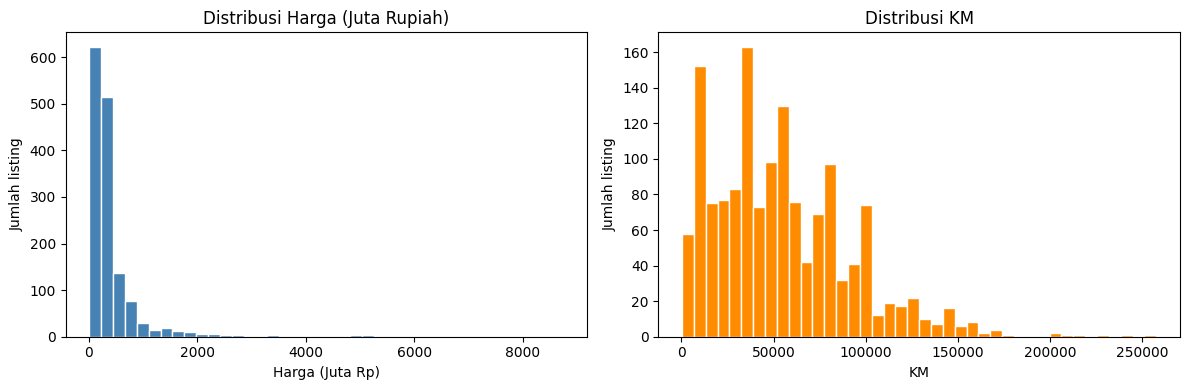

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_model['harga'] / 1e6, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Harga (Juta Rupiah)')
axes[0].set_xlabel('Harga (Juta Rp)')
axes[0].set_ylabel('Jumlah listing')

axes[1].hist(df_model['km'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Distribusi KM')
axes[1].set_xlabel('KM')
axes[1].set_ylabel('Jumlah listing')
plt.tight_layout()
plt.show()


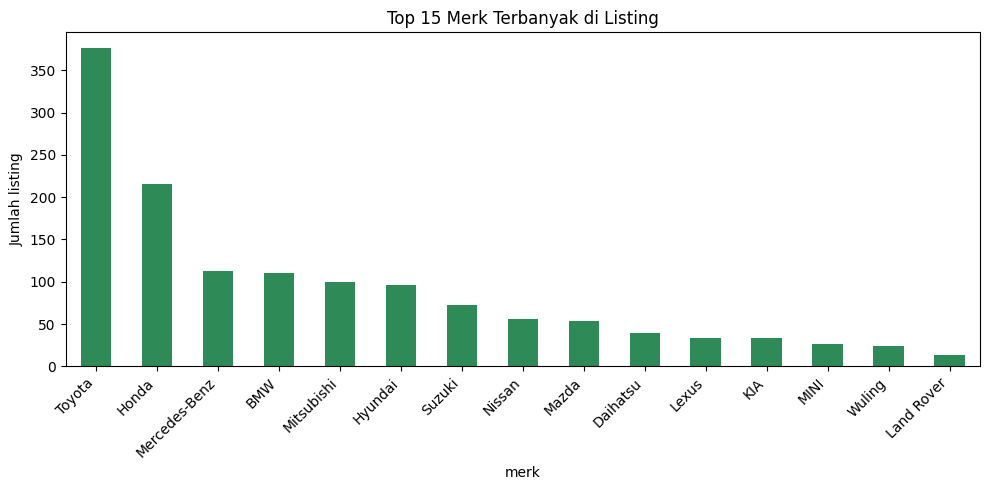

In [14]:
top_merk = df_model['merk'].value_counts().head(15)
plt.figure(figsize=(10, 5))
top_merk.plot(kind='bar', color='seagreen')
plt.title('Top 15 Merk Terbanyak di Listing')
plt.ylabel('Jumlah listing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


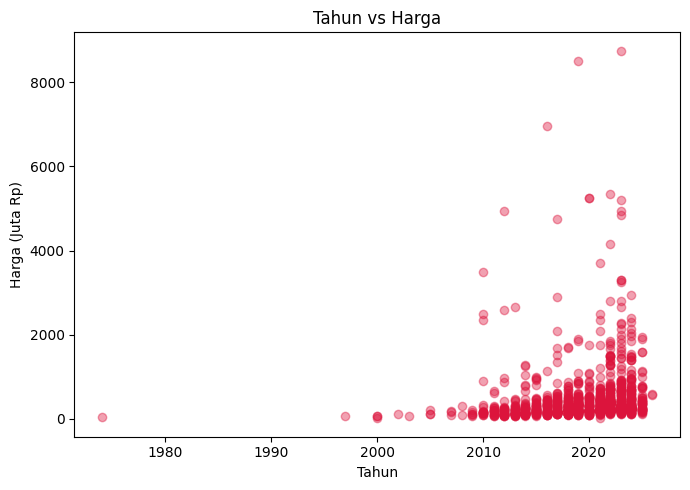

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(df_model['tahun'], df_model['harga'] / 1e6, alpha=0.4, color='crimson')
plt.title('Tahun vs Harga')
plt.xlabel('Tahun')
plt.ylabel('Harga (Juta Rp)')
plt.tight_layout()
plt.show()


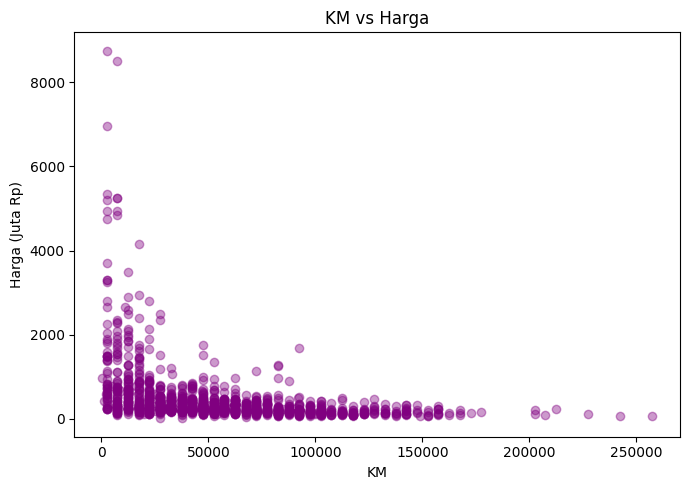

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(df_model['km'], df_model['harga'] / 1e6, alpha=0.4, color='purple')
plt.title('KM vs Harga')
plt.xlabel('KM')
plt.ylabel('Harga (Juta Rp)')
plt.tight_layout()
plt.show()


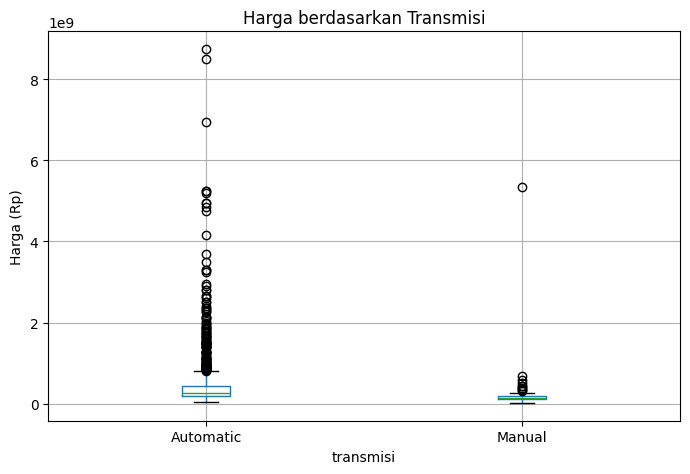

In [17]:
df_model.boxplot(column='harga', by='transmisi', figsize=(7, 5))
plt.title('Harga berdasarkan Transmisi')
plt.suptitle('')
plt.ylabel('Harga (Rp)')
plt.tight_layout()
plt.show()


<Figure size 900x500 with 0 Axes>

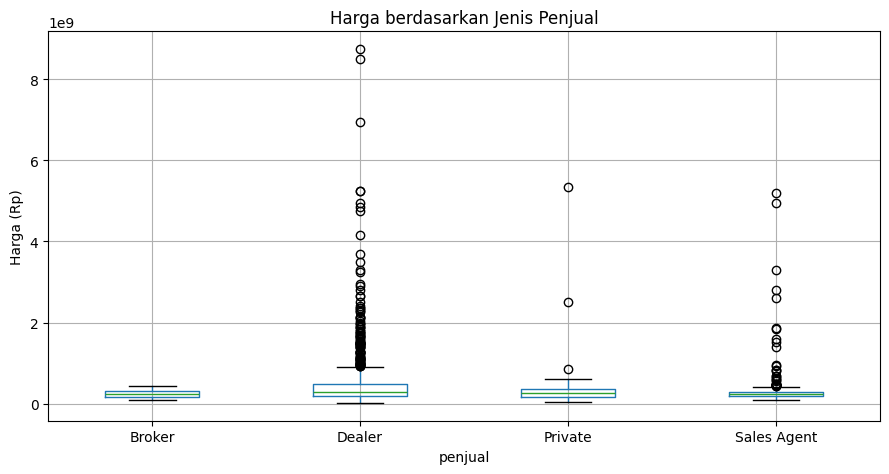

In [18]:
plt.figure(figsize=(9, 5))
df_model.boxplot(column='harga', by='penjual', figsize=(9, 5))
plt.title('Harga berdasarkan Jenis Penjual')
plt.suptitle('')
plt.ylabel('Harga (Rp)')
plt.tight_layout()
plt.show()


In [19]:
# Kolom numerik untuk korelasi: tahun, km, harga, plus semua kolom dummy jenis mobil
# (is_suv, is_mpv, dst) yang nilainya 0/1 sehingga korelasinya juga valid dihitung.
dummy_cols_model = [c for c in df_model.columns if c.startswith('is_')]
numeric_cols = ['tahun', 'km', 'harga'] + dummy_cols_model
numeric_df = df_model[numeric_cols]

corr_matrix = numeric_df.corr()
print(corr_matrix.round(2))


                tahun    km  harga  is_convertible  is_coupe  is_fastback  \
tahun            1.00 -0.59   0.14           -0.08     -0.01         0.03   
km              -0.59  1.00  -0.35           -0.07     -0.18        -0.05   
harga            0.14 -0.35   1.00            0.16      0.29         0.07   
is_convertible  -0.08 -0.07   0.16            1.00     -0.01        -0.00   
is_coupe        -0.01 -0.18   0.29           -0.01      1.00        -0.01   
is_fastback      0.03 -0.05   0.07           -0.00     -0.01         1.00   
is_hatchback    -0.07  0.04  -0.12           -0.02     -0.06        -0.02   
is_mpv           0.01  0.21  -0.14           -0.04     -0.11        -0.03   
is_pickup        0.04 -0.04  -0.01           -0.00     -0.01        -0.00   
is_suv           0.11 -0.03   0.04           -0.06     -0.17        -0.05   
is_sedan        -0.17 -0.09   0.02           -0.02     -0.07        -0.02   
is_truck        -0.03 -0.01  -0.01           -0.01     -0.01        -0.00   

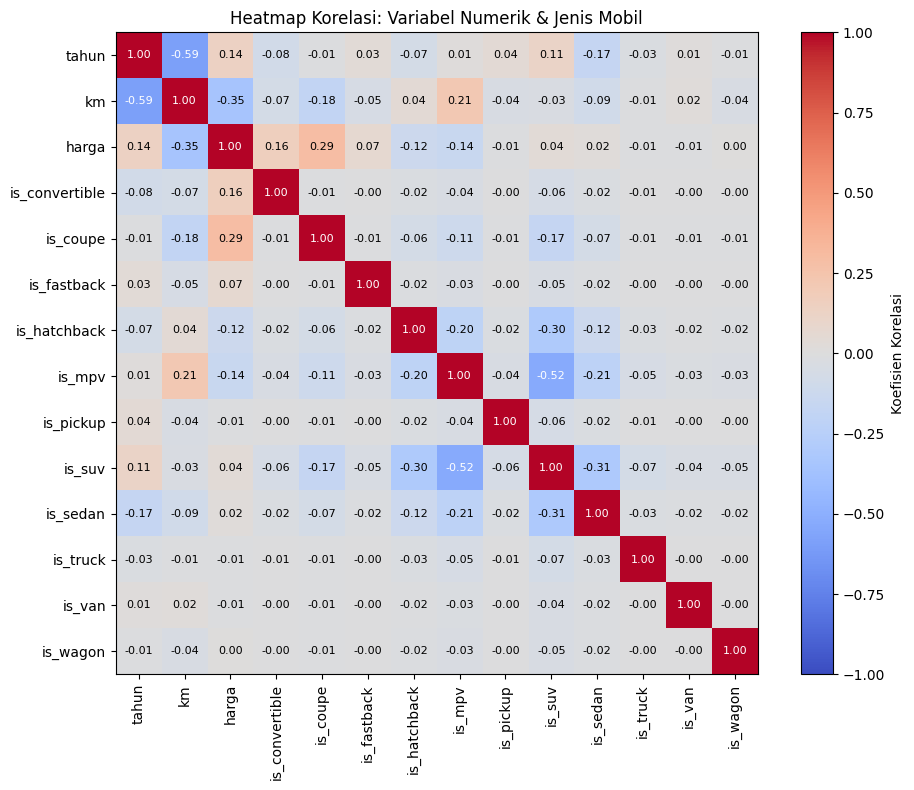

In [20]:
plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, label='Koefisien Korelasi')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# tampilkan angka korelasi di tiap sel
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=8)

plt.title('Heatmap Korelasi: Variabel Numerik & Jenis Mobil')
plt.tight_layout()
plt.show()


## 5. Uji Korelasi dan Regresi Linear Berganda

Sebelum membangun model, uji korelasi terhadap variabel numerik sudah dilakukan di
bagian EDA sebelumnya (lihat heatmap korelasi). Hasilnya jadi dasar pemilihan variabel:
`tahun` dan `km` punya korelasi cukup kuat dengan `harga`, sementara beberapa jenis
mobil (`is_coupe`, `is_suv`) juga menunjukkan pola korelasi yang menarik untuk
diikutkan sebagai prediktor.

**Jenis model:** Regresi Linear Berganda (multiple linear regression) -- dipilih karena
`harga` mobil bekas dipengaruhi oleh banyak faktor sekaligus, bukan cuma satu variabel.
Regresi sederhana (1 prediktor) tidak cukup menangkap kompleksitas tersebut.

**Variabel Dependen (Y):**
- `harga` -- harga jual mobil (Rupiah)

**Variabel Independen (X):**
- `tahun` (numerik) -- tahun produksi mobil
- `km` (numerik) -- jarak tempuh (kilometer)
- `merk` (kategorikal, di-*one-hot encode*) -- merk mobil
- `transmisi` (kategorikal, di-*one-hot encode*) -- Automatic/Manual
- `jenis_mobil` (kategorikal, di-*one-hot encode* lewat kolom dummy `is_suv`, `is_mpv`, dst) -- jenis body mobil

Kolom `tipe` tidak diikutkan ke model ini karena kardinalitasnya sangat tinggi (banyak
tipe yang hanya muncul 1-2 kali), yang berisiko membuat model overfit -- bisa
ditambahkan belakangan kalau mau dieksplorasi lebih lanjut, atau dikelompokkan dulu ke
kategori yang lebih luas. Kolom `lokasi` dan `penjual` juga belum diikutkan ke model
dasar ini, fokus dulu ke variabel yang paling berkaitan langsung dengan kondisi fisik
mobil.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Variabel independen (X): tahun, km (numerik) + merk, transmisi (kategorikal)
# + semua kolom dummy jenis mobil (is_suv, is_mpv, dst)
dummy_cols_model = [c for c in df_model.columns if c.startswith('is_')]
feature_cols = ['tahun', 'km', 'merk', 'transmisi'] + dummy_cols_model

X = df_model[feature_cols]
y = df_model['harga']

categorical_cols = ['merk', 'transmisi']
numeric_cols = ['tahun', 'km'] + dummy_cols_model

# Fix: Use drop='first' to avoid perfect multicollinearity (VIF = inf)
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
], remainder='passthrough')

model = Pipeline([
    ('prep', preprocessor),
    ('lr', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Variabel independen (X):", feature_cols)
print("Variabel dependen (y): harga")
print()
print("R2 (test):", r2_score(y_test, pred))
print("MAE (test):", mean_absolute_error(y_test, pred))

Variabel independen (X): ['tahun', 'km', 'merk', 'transmisi', 'is_convertible', 'is_coupe', 'is_fastback', 'is_hatchback', 'is_mpv', 'is_pickup', 'is_suv', 'is_sedan', 'is_truck', 'is_van', 'is_wagon']
Variabel dependen (y): harga

R2 (test): 0.2937326417755083
MAE (test): 275184056.3273642


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


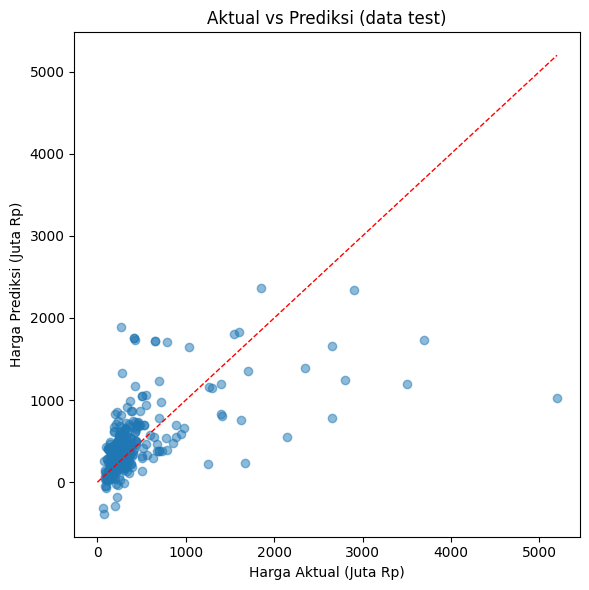

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test / 1e6, pred / 1e6, alpha=0.5)
lims = [0, max(y_test.max(), pred.max()) / 1e6]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('Harga Aktual (Juta Rp)')
plt.ylabel('Harga Prediksi (Juta Rp)')
plt.title('Aktual vs Prediksi (data test)')
plt.tight_layout()
plt.show()


In [23]:
# fit ulang di seluruh data (df_model) untuk melihat arah & besar pengaruh tiap variabel
model.fit(X, y)
lr = model.named_steps['lr']
feat_names = model.named_steps['prep'].get_feature_names_out()

coef_df = pd.DataFrame({'fitur': feat_names, 'koefisien': lr.coef_})
coef_df = coef_df.sort_values('koefisien', ascending=False)
coef_df


,fitur,koefisien
49,remainder__is_coupe,7.529197e+08
34,cat__merk_Porsche,5.867129e+08
23,cat__merk_Land Rover,5.847745e+08
24,cat__merk_Lexus,3.934681e+08
11,cat__merk_Ferrari,3.906400e+08
29,cat__merk_Mercedes-Benz,2.582463e+08
48,remainder__is_convertible,2.440524e+08
0,cat__merk_Audi,9.910076e+07
50,remainder__is_fastback,7.611369e+07
20,cat__merk_Jeep,7.229174e+07


**Catatan interpretasi koefisien:** angka koefisien menunjukkan estimasi tambahan/pengurangan
harga (dalam Rupiah) untuk tiap satuan kenaikan variabel tersebut, dengan variabel lain dianggap
tetap. Untuk variabel kategorikal (`merk`, `transmisi`) yang sudah di-*one-hot encode*, koefisien
menunjukkan selisih harga dibandingkan kategori dasar.

**Hal yang perlu diperhatikan sebelum mengandalkan model ini:**
- Beberapa merk masih punya jumlah listing yang sedikit, sehingga koefisien untuk merk tersebut
  bisa kurang stabil/representatif.
- R² dan MAE di atas dihitung dari satu kali *train-test split*; untuk evaluasi yang lebih
  stabil bisa dicoba *cross-validation*.
- Variabel `tipe`, `lokasi`, dan `penjual` belum diikutkan ke model dasar ini -- bisa dieksplorasi
  lebih lanjut sesuai kebutuhan analisis.


## 6. Uji Asumsi Klasik

Karena model di atas adalah **regresi linear berganda**, perlu dilakukan uji asumsi
klasik untuk memastikan model valid secara statistik: (1) **multikolinearitas**
antar variabel independen, (2) **heteroskedastisitas** pada residual, dan
(3) **normalitas** residual.


### 6.1 Uji Multikolinearitas (VIF)

VIF (*Variance Inflation Factor*) mengukur seberapa besar suatu variabel independen
berkorelasi dengan variabel independen lainnya. **Aturan umum:** VIF > 10 menunjukkan
multikolinearitas yang serius; VIF > 5 perlu diwaspadai.


In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Re-run VIF calculation with the updated model (drop='first')
X_encoded = model.named_steps['prep'].transform(X)
encoded_feature_names = model.named_steps['prep'].get_feature_names_out()

X_encoded_df = pd.DataFrame(X_encoded.toarray(), columns=encoded_feature_names)

vif_data = pd.DataFrame()
vif_data['fitur'] = encoded_feature_names
vif_data['VIF'] = [variance_inflation_factor(X_encoded_df.values, i)
                    for i in range(X_encoded_df.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))
print()
n_high_vif = (vif_data['VIF'] > 10).sum()
print(f"Jumlah fitur dengan VIF > 10 (multikolinearitas serius): {n_high_vif}")

                    fitur         VIF
         remainder__tahun 1506.582384
         cat__merk_Toyota  378.365924
          cat__merk_Honda  216.689619
  cat__merk_Mercedes-Benz  114.217959
            cat__merk_BMW  111.373425
     cat__merk_Mitsubishi  101.428580
        cat__merk_Hyundai   97.237522
         cat__merk_Suzuki   74.339060
         cat__merk_Nissan   57.338504
          cat__merk_Mazda   55.122258
       cat__merk_Daihatsu   41.265351
          cat__merk_Lexus   34.978965
            cat__merk_KIA   34.099663
           cat__merk_MINI   27.094622
         cat__merk_Wuling   25.114743
        remainder__is_suv   19.554185
     cat__merk_Land Rover   15.096357
        remainder__is_mpv   12.415518
        cat__merk_Porsche   12.081089
           cat__merk_Ford   11.335963
          cat__merk_Chery   11.010369
           cat__merk_Jeep    9.972240
      cat__merk_Chevrolet    8.027193
         cat__merk_Subaru    7.032889
      remainder__is_sedan    6.409897
          ca

### 6.2 Uji Heteroskedastisitas (Residual Plot)

Residual (selisih nilai aktual - prediksi) diplot terhadap nilai prediksi. **Asumsi
terpenuhi** kalau titik-titik tersebar acak di sekitar garis 0 tanpa pola corong
(melebar/menyempit) -- itu disebut *homoskedastisitas*. Kalau ada pola corong, berarti
*heteroskedastisitas* (varians residual tidak konstan).


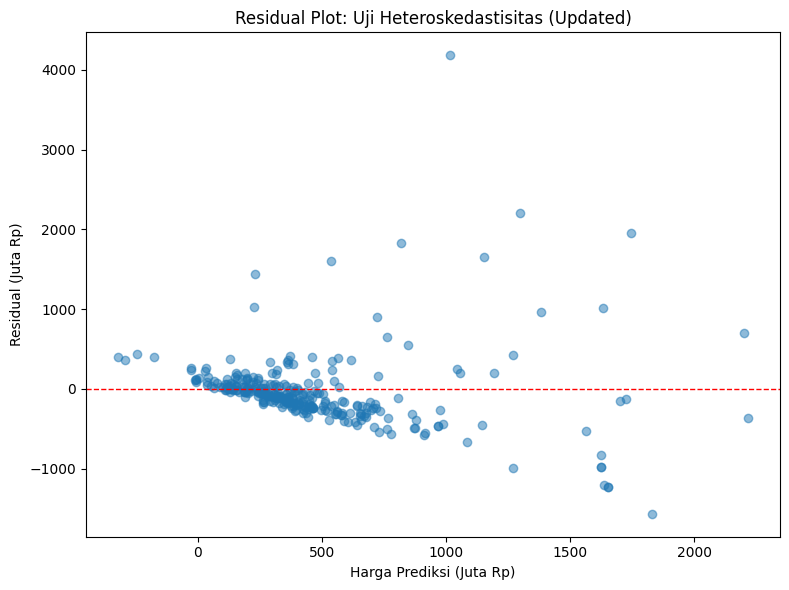

In [25]:
# Re-calculate residuals and re-plot
residuals = y_test - model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(model.predict(X_test) / 1e6, residuals / 1e6, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Harga Prediksi (Juta Rp)')
plt.ylabel('Residual (Juta Rp)')
plt.title('Residual Plot: Uji Heteroskedastisitas (Updated)')
plt.tight_layout()
plt.show()

### 6.3 Uji Normalitas Residual

Diuji dengan dua cara: **histogram residual** (visual, bentuknya harus mendekati
kurva normal/lonceng simetris) dan **uji Shapiro-Wilk** (statistik, H0 = residual
berdistribusi normal; kalau p-value < 0.05 maka H0 ditolak, artinya residual
**tidak** berdistribusi normal).


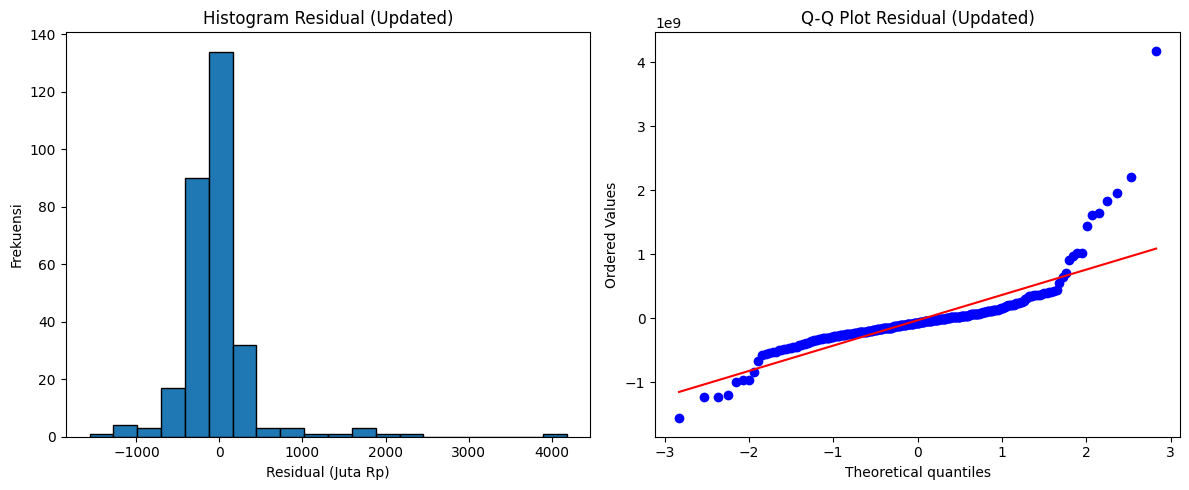

Shapiro-Wilk statistic: 0.7045, p-value: 0.0000
-> p-value < 0.05: residual TIDAK berdistribusi normal (H0 ditolak).


In [26]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram residual
axes[0].hist(residuals / 1e6, bins=20, edgecolor='black')
axes[0].set_xlabel('Residual (Juta Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Histogram Residual (Updated)')

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot Residual (Updated)')

plt.tight_layout()
plt.show()

# Uji Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("-> p-value < 0.05: residual TIDAK berdistribusi normal (H0 ditolak).")
else:
    print("-> p-value >= 0.05: tidak cukup bukti untuk menolak normalitas residual.")

**Catatan:** Uji Shapiro-Wilk cukup sensitif pada ukuran sampel besar (>1000 baris) --
sering menghasilkan p-value kecil meskipun penyimpangan dari normalitas sebenarnya
kecil/tidak terlalu bermasalah secara praktis. Untuk sampel besar, lebih baik
mengandalkan visual (histogram & Q-Q plot) dibanding p-value semata.


## 7. Perbaikan Model: Transformasi Log & Usia Mobil

Dari hasil bagian 5 & 6, terlihat tiga masalah yang saling berkaitan:

1. **Distribusi `harga` sangat *right-skewed*** (mean jauh di atas median, ada outlier
   mobil mewah sampai miliaran) -- ini diduga jadi akar dari R² yang rendah, residual
   tidak normal, dan pola corong (heteroskedastisitas) di residual plot.
2. **VIF `tahun` sangat tinggi (>300)** -- ini kemungkinan *false alarm*: `tahun` tidak
   di-*center* (rentang 1974-2026, jauh dari nol), sehingga VIF membengkak secara
   struktural, bukan karena `tahun` benar-benar berkorelasi kuat dengan variabel lain.

**Perbaikan yang dicoba:**
- Variabel dependen diganti jadi **`log(harga)`** -- transformasi log memampatkan
  rentang nilai yang ekstrem, sering memperbaiki normalitas residual & heteroskedastisitas
  sekaligus.
- Variabel `tahun` diganti jadi **`usia_mobil` = 2026 - tahun** -- secara matematis ini
  cuma transformasi linear (tidak mengubah kekuatan model), tapi menghindari skala
  angka tahun yang jauh dari nol, sehingga VIF jadi lebih representatif, dan lebih
  mudah diinterpretasi ("makin tua usia mobil, harga turun sekian").


In [27]:
df_model2 = df_model.copy()
df_model2['usia_mobil'] = 2026 - df_model2['tahun']
df_model2['log_harga'] = np.log(df_model2['harga'])

print(df_model2[['tahun', 'usia_mobil', 'harga', 'log_harga']].head())
print()
print('Skewness harga asli   :', df_model2['harga'].skew().round(3))
print('Skewness log(harga)   :', df_model2['log_harga'].skew().round(3))


   tahun  usia_mobil        harga  log_harga
0   2013          13  230000000.0  19.253590
1   2022           4  189000000.0  19.057258
2   2024           2  685000000.0  20.344929
3   2017           9  132000000.0  18.698312
4   2018           8  160000000.0  18.890684

Skewness harga asli   : 6.295
Skewness log(harga)   : 1.037


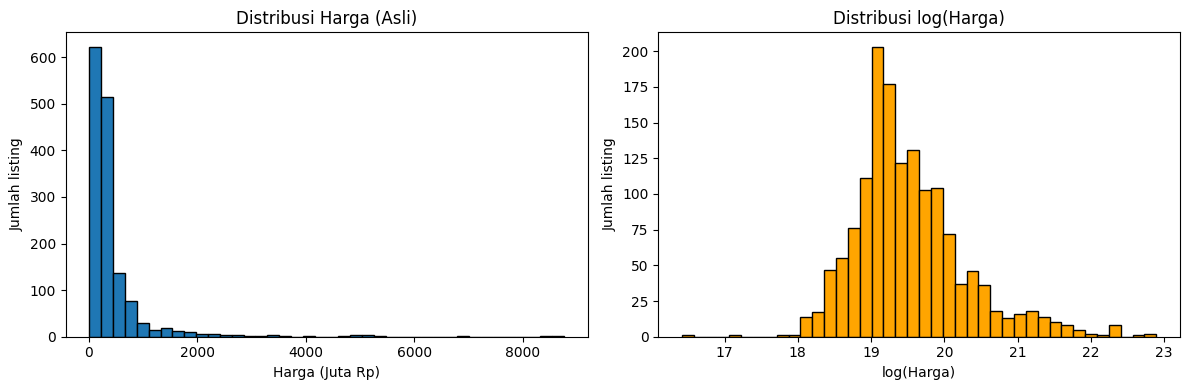

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_model2['harga'] / 1e6, bins=40, edgecolor='black')
axes[0].set_title('Distribusi Harga (Asli)')
axes[0].set_xlabel('Harga (Juta Rp)')
axes[0].set_ylabel('Jumlah listing')

axes[1].hist(df_model2['log_harga'], bins=40, edgecolor='black', color='orange')
axes[1].set_title('Distribusi log(Harga)')
axes[1].set_xlabel('log(Harga)')
axes[1].set_ylabel('Jumlah listing')

plt.tight_layout()
plt.show()


In [29]:
# Variabel independen (X): usia_mobil, km (numerik) + merk, transmisi (kategorikal)
# + semua kolom dummy jenis mobil
# Variabel dependen (y): log_harga (BUKAN harga mentah)
feature_cols2 = ['usia_mobil', 'km', 'merk', 'transmisi'] + dummy_cols_model

X2 = df_model2[feature_cols2]
y2 = df_model2['log_harga']

preprocessor2 = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
], remainder='passthrough')

model2 = Pipeline([
    ('prep', preprocessor2),
    ('lr', LinearRegression())
])

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

model2.fit(X_train2, y_train2)
pred_log2 = model2.predict(X_test2)

print("Variabel independen (X):", feature_cols2)
print("Variabel dependen (y): log_harga")
print()
print("R2 (test, skala log)  :", r2_score(y_test2, pred_log2))

# Konversi balik ke skala Rupiah untuk MAE yang lebih bermakna
pred_rupiah2 = np.exp(pred_log2)
actual_rupiah2 = np.exp(y_test2)
print("MAE (test, skala Rupiah, setelah exp-back):", mean_absolute_error(actual_rupiah2, pred_rupiah2))


Variabel independen (X): ['usia_mobil', 'km', 'merk', 'transmisi', 'is_convertible', 'is_coupe', 'is_fastback', 'is_hatchback', 'is_mpv', 'is_pickup', 'is_suv', 'is_sedan', 'is_truck', 'is_van', 'is_wagon']
Variabel dependen (y): log_harga

R2 (test, skala log)  : 0.5396058180840186
MAE (test, skala Rupiah, setelah exp-back): 202648895.89311957


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


**Perbandingan dengan model awal (bagian 5):**

| Model | R² (test) | MAE (test) |
|---|---|---|
| Awal (`harga` mentah, `tahun` mentah) | ≈ 0.29 | ≈ 275 juta |
| Setelah log + usia mobil | *lihat output di atas* | *lihat output di atas* |

Jalankan cell di atas untuk isi baris kedua, lalu bandingkan langsung -- ini bagus untuk
dibahas di laporan bab 4 sebagai proses iterasi perbaikan model.


### 7.1 Cek Ulang VIF Setelah `usia_mobil`


In [30]:
X_encoded2 = model2.named_steps['prep'].transform(X2)
if hasattr(X_encoded2, 'toarray'):  # OneHotEncoder bisa mengembalikan sparse matrix
    X_encoded2 = X_encoded2.toarray()
encoded_feature_names2 = model2.named_steps['prep'].get_feature_names_out()
X_encoded_df2 = pd.DataFrame(X_encoded2, columns=encoded_feature_names2)

vif_data2 = pd.DataFrame()
vif_data2['fitur'] = encoded_feature_names2
vif_data2['VIF'] = [variance_inflation_factor(X_encoded_df2.values, i)
                     for i in range(X_encoded_df2.shape[1])]
vif_data2 = vif_data2.sort_values('VIF', ascending=False)

print(vif_data2.head(10).to_string(index=False))
print()
n_high_vif2 = (vif_data2['VIF'] > 10).sum()
print(f"Jumlah fitur dengan VIF > 10 setelah perbaikan: {n_high_vif2} (sebelumnya: 12)")


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


                  fitur       VIF
      remainder__is_suv 17.210125
      remainder__is_mpv 11.074991
       cat__merk_Toyota  9.603536
  remainder__usia_mobil  8.726380
          remainder__km  7.599845
        cat__merk_Honda  6.827225
    remainder__is_sedan  5.851836
remainder__is_hatchback  5.208726
cat__merk_Mercedes-Benz  4.137448
          cat__merk_BMW  4.103082

Jumlah fitur dengan VIF > 10 setelah perbaikan: 2 (sebelumnya: 12)


### 7.2 Cek Ulang Heteroskedastisitas & Normalitas Residual (Model Log)

Residual di sini dihitung pada skala **log**, karena itulah skala yang sebenarnya
dipakai untuk fitting model.


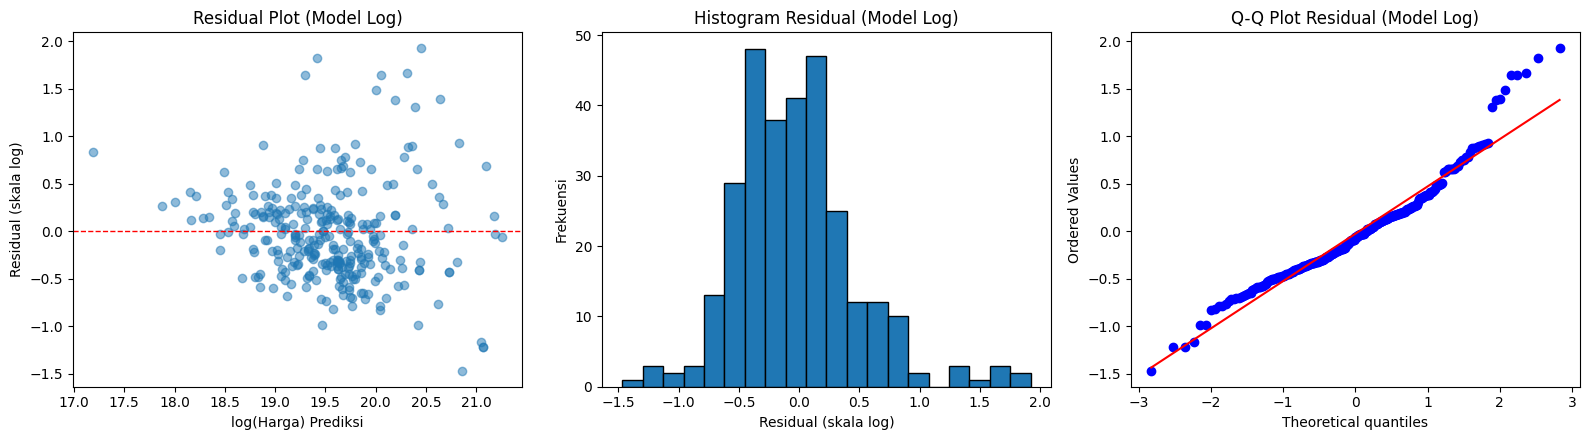

Shapiro-Wilk (model log) statistic: 0.9527, p-value: 0.0000
-> p-value < 0.05: residual TIDAK berdistribusi normal (H0 ditolak).

Bandingkan visual residual plot & Q-Q plot ini dengan versi model awal di bagian 6 --
perhatikan apakah pola corong (heteroskedastisitas) berkurang, dan apakah titik-titik
di Q-Q plot lebih mendekati garis merah dibanding sebelumnya.


In [31]:
residuals_log = y_test2 - pred_log2

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(pred_log2, residuals_log, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('log(Harga) Prediksi')
axes[0].set_ylabel('Residual (skala log)')
axes[0].set_title('Residual Plot (Model Log)')

axes[1].hist(residuals_log, bins=20, edgecolor='black')
axes[1].set_xlabel('Residual (skala log)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Histogram Residual (Model Log)')

stats.probplot(residuals_log, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot Residual (Model Log)')

plt.tight_layout()
plt.show()

shapiro_stat2, shapiro_p2 = stats.shapiro(residuals_log)
print(f"Shapiro-Wilk (model log) statistic: {shapiro_stat2:.4f}, p-value: {shapiro_p2:.4f}")
if shapiro_p2 < 0.05:
    print("-> p-value < 0.05: residual TIDAK berdistribusi normal (H0 ditolak).")
else:
    print("-> p-value >= 0.05: tidak cukup bukti untuk menolak normalitas residual.")
print()
print("Bandingkan visual residual plot & Q-Q plot ini dengan versi model awal di bagian 6 --")
print("perhatikan apakah pola corong (heteroskedastisitas) berkurang, dan apakah titik-titik")
print("di Q-Q plot lebih mendekati garis merah dibanding sebelumnya.")


**Catatan untuk laporan:** Transformasi log umumnya membantu pada data harga yang
skewed, tapi belum tentu membuat semua asumsi klasik terpenuhi sempurna -- apalagi
kalau outlier ekstrem (misal mobil Ferrari/Porsche di tengah dominasi mobil keluarga)
tetap ada. Kalau setelah log-transform residual masih belum normal, opsi lanjutan yang
bisa dibahas di laporan (sebagai *future work*, tidak harus dieksekusi semua):
- Menganalisis outlier mobil mewah secara terpisah (model khusus, atau di-exclude dengan
  alasan yang dijelaskan).
- Mencoba model non-linear (Random Forest, Gradient Boosting) sebagai pembanding, untuk
  menunjukkan bahwa keterbatasan ini bukan soal kesalahan coding, tapi karakteristik data.
- Winsorizing / capping outlier harga pada persentil tertentu (misal 1% & 99%).
